c:\Users\joaov\Downloads\tendencias-cc-main\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\joaov\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\joaov\Downloads\tendencias-cc-main\.venv\Lib\site-

     id  tamanho
0  M036      766
1  M037      726
2  M038      689
3  M040      630
4  M039      626

=== size200_overlap20 ===
id_manifestacao
M036    6
M037    5
M038    6
M039    5
M040    5
dtype: int64

=== size500_overlap100 ===
id_manifestacao
M036    2
M037    2
M038    2
M039    2
M040    2
dtype: int64


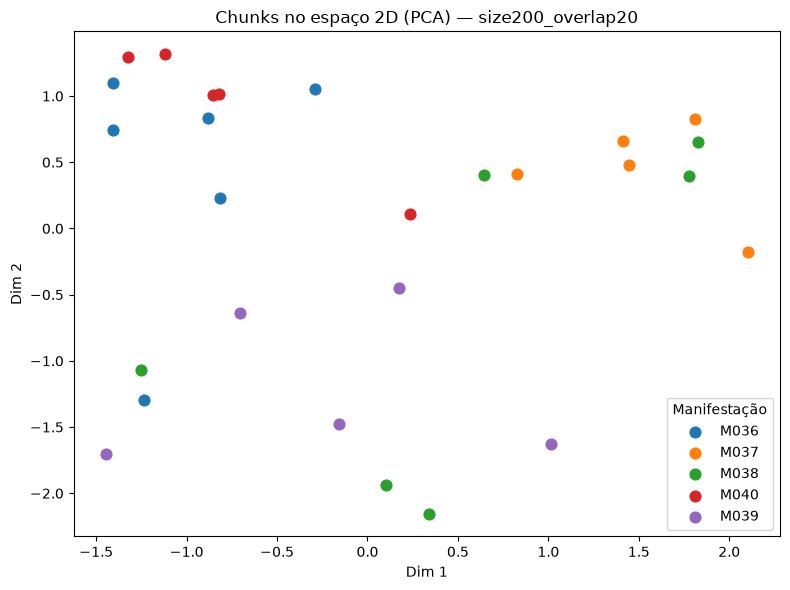

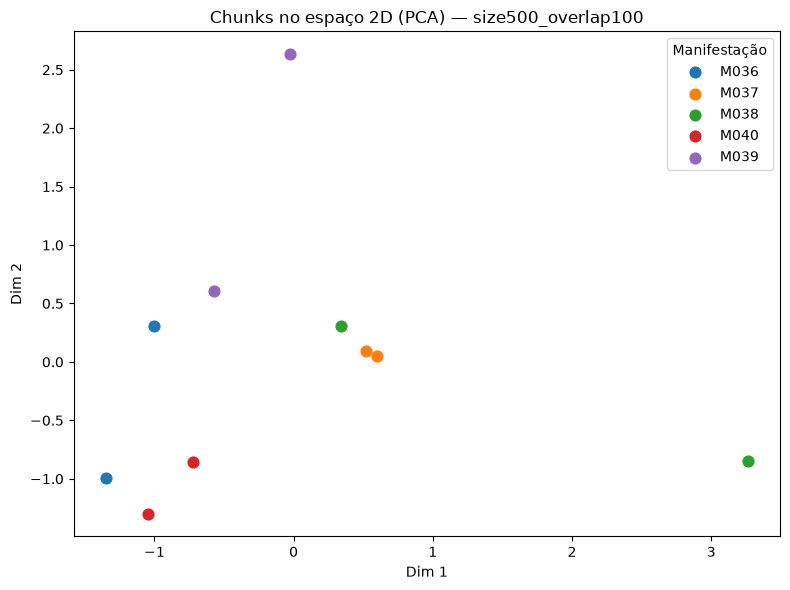


--- Chunks (size=200) da manifestação M036 ---
[0] Gostaria de registrar uma reclamação detalhada sobre a situação crítica da infraestrutura no bairro Jardim Europa

[1] . Há mais de seis meses, as principais vias de acesso, como a Rua dos Lírios e a Avenida Central, apresentam buracos enormes que estão provocando constantes danos mecânicos aos veículos dos moradores

[2] dos moradores e transporte público

[3] . Além disso, quando chove, a situação piora drasticamente pois a água encobre as crateras, resultando em acidentes graves com motociclistas

[4] . A iluminação pública no trecho final da rua também está completamente apagada há três semanas, deixando os pedestres expostos ao risco de assaltos ao retornarem do trabalho à noite

[5] . Solicitamos uma intervenção emergencial da prefeitura para recapeamento asfáltico e manutenção da iluminação.


--- Chunks (size=500) da manifestação M036 ---
[0] Gostaria de registrar uma reclamação detalhada sobre a situação crítica da infraestru

In [4]:
# ==== Entrega 3: Chunking de Manifestações Longas ====

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from langchain_text_splitters import RecursiveCharacterTextSplitter
# --- 0. Carregar os dados (igual às partes 1 e 2) ---
with open('../data/manifestacoes.json', 'r', encoding='utf-8') as f:
    dados = json.load(f)
df = pd.DataFrame(dados)

modelo_emb = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# --- 1. Selecionar as 5 manifestações mais longas ---
df['tamanho'] = df['texto'].astype(str).apply(len)
top5 = df.sort_values('tamanho', ascending=False).head(5).reset_index(drop=True)
print(top5[['id', 'tamanho']])

# --- 2. Definir configurações de chunking a testar ---
configs = [
    {"chunk_size": 200, "chunk_overlap": 20},
    {"chunk_size": 500, "chunk_overlap": 100},
]

def gerar_chunks(top5_df, chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    registros = []
    for _, row in top5_df.iterrows():
        chunks = splitter.split_text(row['texto'])
        for pos, chunk in enumerate(chunks):
            registros.append({
                'id_manifestacao': row['id'],
                'pos': pos,
                'chunk': chunk
            })
    return pd.DataFrame(registros)

resultados = {}
for cfg in configs:
    key = f"size{cfg['chunk_size']}_overlap{cfg['chunk_overlap']}"
    resultados[key] = gerar_chunks(top5, cfg['chunk_size'], cfg['chunk_overlap'])
    print(f"\n=== {key} ===")
    print(resultados[key].groupby('id_manifestacao').size())

# --- 3. Vetorizar chunks (embeddings) e reduzir para 2D ---
def visualizar_chunks(chunks_df, titulo, metodo='pca'):
    X = modelo_emb.encode(chunks_df['chunk'].tolist(), convert_to_numpy=True)

    if metodo == 'pca':
        reducer = PCA(n_components=2, random_state=42)
    else:
        reducer = TSNE(n_components=2, random_state=42,
                        perplexity=min(30, len(X) - 1))
    coords = reducer.fit_transform(X)

    chunks_df = chunks_df.copy()
    chunks_df['x'], chunks_df['y'] = coords[:, 0], coords[:, 1]

    plt.figure(figsize=(8, 6))
    for mid in chunks_df['id_manifestacao'].unique():
        sub = chunks_df[chunks_df['id_manifestacao'] == mid]
        plt.scatter(sub['x'], sub['y'], label=mid, s=60)
    plt.title(titulo)
    plt.legend(title='Manifestação')
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.tight_layout()
    plt.show()

    return chunks_df

chunks_vis = {}
for key, chunks_df in resultados.items():
    chunks_vis[key] = visualizar_chunks(chunks_df, f'Chunks no espaço 2D (PCA) — {key}', metodo='pca')

# --- 4. Exemplo de chunk "cortado" vs "completo", para justificar as respostas ---
exemplo_pequeno = resultados['size200_overlap20']
exemplo_grande = resultados['size500_overlap100']

id_exemplo = top5.iloc[0]['id']
print("\n--- Chunks (size=200) da manifestação", id_exemplo, "---")
for _, r in exemplo_pequeno[exemplo_pequeno['id_manifestacao'] == id_exemplo].iterrows():
    print(f"[{r['pos']}] {r['chunk']}\n")

print("\n--- Chunks (size=500) da manifestação", id_exemplo, "---")
for _, r in exemplo_grande[exemplo_grande['id_manifestacao'] == id_exemplo].iterrows():
    print(f"[{r['pos']}] {r['chunk']}\n")